# DEGADIS Plume Dispersion

This is the plume dispersion model described in the DEGADIS user manual.

In [1]:
using GasDispersion, Plots

## Scenario Parameters

In [3]:
# physics parameters
g = 9.81    # gravitational acceleration, 9.81 m/s²
R = 8.31446261815324 # universal gas constant, J/mol/K

8.31446261815324

In [4]:
# ambient conditions
uₐ   = 3.0                 # ambient wind-speed, m/s
Tₐ   = 298.0               # ambient temeprature, K
pₐ   = 101325              # ambient pressure, Pa
MWₐ = 28.960               # molar weight air, kg/kmol
ρₐ  = (pₐ*MWₐ)/(R*Tₐ)/1000 # density of air, kg/m³

1.1843081577564905

In [5]:
# jet conditions
qⱼ  = 5.0                  # mass emission rate of jet, kg/s
D   = 0.50                 # diametery of jet, m
h   = 2.5                  # release height, m
Tⱼ  = 273.0                # release temperature, K
MWⱼ = 44.0                 # molar weight of jet, kg/kmol
ρⱼ  = (pₐ*MWⱼ)/(R*Tⱼ)/1000 # density of jet, kg/m³
Aₕ  = (π/4)*D^2
Qⱼ  = qⱼ/ρⱼ
uⱼ  = Qⱼ/Aₕ

12.964854807584974

In [6]:
# model parameters
γ  = 1-(ρₐ/ρⱼ)

params = [ ρₐ, uₐ, γ ]

3-element Vector{Float64}:
 1.1843081577564905
 3.0
 0.39703477730323355

## Dispersion Equations

In [13]:
using Roots, ForwardDiff

# Stability Class D
tₐᵥ = 18.3 # averaging time, s
σyₐ(x) = (0.136*(tₐᵥ/600)^0.2)*(x^0.9)
σzₐ(x) = 0.04134*(x^1.1737)*exp(-0.0316*log(x)^2)
∂ₓσyₐσzₐ(t) = ForwardDiff.derivative(x -> σyₐ(x)*σzₐ(x), float(t))

function sy(sysz, x)
    sya = σyₐ(x)
    sza = σzₐ(x)
    sy = find_zero(sy -> (sya-sza)*(sya+sza) + (sysz/sy - sy)*(sysz/sy + sy), (0.0, max(sysz, 10.0)) )
#    sy = find_zero(sy -> (sya-sza)*(sya+sza) + (sysz/sy - sy)*(sysz/sy + sy), √sysz)
    
end

┌ Info: Precompiling ForwardDiff [f6369f11-7733-5829-9624-2563aa707210]
└ @ Base loading.jl:1317


sy (generic function with 1 method)

# Air Entrainment

In [9]:
"""
    perim(a, b)

Approximates the perimeter of the ellipse with semi-major axis a and semi-minor axis b

Uses the following approximation by Ramanujan

C ≈ π*(a+b)*(1 + 3h/(10+√(4-3h)))

where h = (a-b)²/(a+b)²

# Examples
```julia-repl
julia> perim(2,3)
15.865439589251233
```
"""
function perim(a, b)
    if a<b
        a, b = b, a
    end
    
    h = ((a-b)/(a+b))^2
    
    perim = π*(a+b)*(1 + 3h/(10+√(4-3h)))
end

perim

# Model Parameters

In [10]:
using SpecialFunctions

# additional parameters
δ  = 2.15
λ² = 1.42
λ  = √λ²

k₁ = 2π*erf((δ/2)*√(π/2))^2
k₂ = (2π/(1+λ²))*erf((δ/2)*√((π/2)*(1+λ²)))^2
k₃ = π*δ^2
k₄ = (2π/λ²)*erf((δ*λ/2)*√(π/2))^2
k₅ = (π/λ²)*erf((δ*λ/2)*√(π))^2
k₆ = (2π/(1+2λ²))*erf((δ/2)*√((π/2)*(1+2λ²)))^2

α1 = 0.028
α2 = 0.37
cd = 0.2

┌ Info: Precompiling SpecialFunctions [276daf66-3868-5448-9aa4-cd146d93841b]
└ @ Base loading.jl:1317


0.2

# Model

In [11]:
# Model is the linear system A*dy = B

A = zeros(4,4)
B = zeros(4)
dy = zeros(6)


function model!(dy, y, p, s)
    ρₐ, uₐ, γ = p
    Cc, σyσz, θ, uc, x, zⱼ = y
    
    σyσz = abs(σyσz)
    σy = sy(σyσz, x)
    σz = σyσz/σy
    Pe = perim(δ*σy, δ*σz)

    E₁ = α1*ρₐ*Pe*uc
    E₂ = α2*ρₐ*Pe*uₐ*abs(sin(θ))*cos(θ)
    E₃ = k₃*ρₐ*uₐ*∂ₓσyₐσzₐ(x)*cos(θ)
    
    drag = 0.5*cd*Pe*ρₐ*(uₐ*sin(θ))^2

    # contaminant mass balance
    # A11*∂ₛ(Cc) + A12*∂ₛ(σyσz) + A13*∂ₛ(θ) + A14*∂ₛ(uc) ~ B1
    A[1,1] = (k₁*uₐ*cos(θ)+k₂*uc)*σyσz 
    A[1,2] = (k₁*uₐ*cos(θ)+k₂*uc)*Cc
    A[1,3] = -k₁*uₐ*sin(θ)*Cc*σyσz
    A[1,4] = k₂*Cc*σyσz
    B[1]   = 0.0

    # total mass balance
    # A21*∂ₛ(Cc) + A22*∂ₛ(σyσz) + A23*∂ₛ(θ) + A24*∂ₛ(uc) ~ B2
    A[2,1] = 0.0 
    A[2,2] = ρₐ*(k₁*uₐ*cos(θ)+k₂*uc)
    A[2,3] = -ρₐ*k₃*uₐ*sin(θ)*σyσz
    A[2,4] = ρₐ*k₄*σyσz
    B[2]   = E₁ + E₂ + E₃

    # z-direction momentum balance
    # A31*∂ₛ(Cc) + A32*∂ₛ(σyσz) + A33*∂ₛ(θ) + A34*∂ₛ(uc) ~ B3
    A[3,1] = ( k₁*uₐ^2*cos(θ)^2*sin(θ) + 2*k₂*uₐ*uc*cos(θ)*sin(θ) + k₆*uc^2*sin(θ) )*γ*σyσz
    A[3,2] = ρₐ*(k₃*uₐ^2*cos(θ)^2*sin(θ) + 2*k₄*uₐ*uc*cos(θ)*sin(θ) + k₅*uc^2*sin(θ)) + (k₁*uₐ^2*cos(θ)^2*sin(θ) + 2*k₂*uₐ*uc*cos(θ)*sin(θ) + k₆*uc^2*sin(θ))*γ*Cc
    A[3,3] = ( ρₐ*(-2*k₃*uₐ^2*cos(θ)*sin(θ)^2 + k₃*uₐ^2*cos(θ)^3 - 2*k₄*uₐ*uc*sin(θ)^2 + 2*k₄*uₐ*uc*cos(θ)^2 + k₅*uc^2*cos(θ))*σyσz
               +  (-2*k₁*uₐ^2*cos(θ)*sin(θ)^2 + k₁*uₐ^2*cos(θ)^3 - 2*k₂*uₐ*uc*sin(θ)^2 + 2*k₂*uₐ*uc*cos(θ)^2 + k₆*uc^2*cos(θ))*γ*Cc*σyσz )
    A[3,4] = ρₐ*(2*k₄*uₐ*cos(θ)*sin(θ) + 2*k₅*uc*sin(θ))*σyσz + (2*k₂*uₐ*cos(θ)*sin(θ) + 2*k₆*uc*sin(θ))*Cc*σyσz 
    B[3]   = -k₁*g*γ*Cc*σyσz - sign(θ)*(drag)*cos(θ)

    # x-direction momentum balance
    # A41*∂ₛ(Cc) + A42*∂ₛ(σyσz) + A43*∂ₛ(θ) + A44*∂ₛ(uc) ~ B4
    A[4,1] = (k₁*uₐ^2*cos(θ)^3 + 2*k₂*uₐ*uc*cos(θ)^2 + k₆*uc^2*cos(θ))*γ*σyσz
    A[4,2] = ρₐ*(k₃*uₐ^2*cos(θ)^3 + 2*k₄*uₐ*uc*cos(θ)^2 + k₅*uc^2*cos(θ)) + (k₁*uₐ^2*cos(θ)^3 + 2*k₂*uₐ*uc*cos(θ)^2 + k₆*uc^2*cos(θ))*γ*Cc
    A[4,3] = ( ρₐ*(-3*k₃*uₐ^2*cos(θ)^2*sin(θ) - 4*k₄*uₐ*uc*cos(θ)*sin(θ) - k₅*uc^2*sin(θ))*σyσz
               +  (-3*k₁*uₐ^2*cos(θ)^2*sin(θ) - 4*k₂*uₐ*uc*cos(θ)*sin(θ) - k₆*uc^2*sin(θ))*γ*Cc*σyσz )
    A[4,4] = ρₐ*(2*k₄*uₐ*cos(θ)^2 + 2*k₅*uc*cos(θ))*σyσz + (2*k₂*uₐ*cos(θ)^2 + 2*k₆*uc*cos(θ))*γ*Cc*σyσz
    B[4]   = uₐ*(E₁+E₂+E₃) + (drag)*abs(sin(θ))

    dy[1:4] = A\B
    dy[5] = cos(θ)
    dy[6] = sin(θ)
    
    if dy[1] > 0
        dy[1] = 0.0
    end
    
    if dy[2] < 0
        dy[2] = 0.0
    end
    
end

model! (generic function with 1 method)

# Initial Conditions

In [12]:
# initial conditions

SD = 7.7*(1-exp(-0.48*√((ρⱼ*uⱼ)/(ρₐ*uₐ))))

J  = (ρⱼ/ρₐ)*(uⱼ/uₐ)^2

Fr = (ρₐ*uₐ^2)/(g*D*(ρⱼ-ρₐ))
Fr = if ( (ρⱼ-ρₐ)>0 ) min(Fr, 1.688) else 1.688 end

if J < 0.036
    aⱼ = 18.519*J
    bⱼ = 0.4
elseif J < 10.0
    aⱼ = exp( 0.2476+0.3016*log(Fr)+0.24386*log(J) )
    bⱼ = 0.4
elseif J < 50.0
    aⱼ = exp( 0.405465+0.131386*log(J)+0.054931*log(J)^2 )
    bⱼ = exp( -0.744691-0.074525*log(J) )
elseif J < 600.0
    aⱼ = exp( -2.55104+1.49202*log(J)-0.097623*log(J)^2 )
    bⱼ = exp( -0.446718-0.150694*log(J) )
else
    aⱼ = exp( 1.44099+0.243045*log(J) )
    bⱼ = exp( -0.446718-0.150694*log(J) )
end

xD(zD; a=aⱼ, b=bⱼ) = (zD/a)^(1/b)
zD = find_zero( zD -> zD^2 + xD(zD)^2 - SD, SD )

x₀  = xD(zD)*D
z₀ = zD*D
zⱼ₀ = z₀ + h

@assert x₀/D >= 0

θ₀ = if (x₀/D > 0) atan(bⱼ*z₀/x₀) else π/2 end

Cc₀   = ρⱼ
uc₀   = uⱼ-uₐ*cos(θ₀)
σyσz₀ = Qⱼ*(k₁*uₐ*cos(θ₀) + k₂*uc₀)

σy₀ = √(σyσz₀)
σz₀ = σy₀

y₀ = [ Cc₀, σyσz₀, θ₀, uc₀, x₀, zⱼ₀ ]

6-element Vector{Float64}:
  1.9641400750439029
 89.64253133932192
  1.3749933316365894
 12.381192060776876
  0.08582799959384883
  3.676904881032539

In [14]:
using DifferentialEquations

span = (0.0, 40.0)
prb = ODEProblem(model!, y₀, span, params)

# enforce domains
function domain_check(y,p,s)
    return any([
        y[1] < 0,  # concentration strictly positive
        y[2] < 0,  # width of plume strictly positive
        # y[3]  ,  θ can be positive or negative
        y[4] < 0,  # windspeed strictly positive
        y[5] < 0,  # downwind distance strictly positive
        # y[6]  ,  z can go negative, at which point integration stops
    ])
end

# halt the solver once zⱼ drops below zero (i.e. the center line is below ground)
condition(y,s,integrator) = y[6]<0
affect!(integrator) = terminate!(integrator)
cb = DiscreteCallback(condition,affect!)

┌ Info: Precompiling DifferentialEquations [0c46a032-eb83-5123-abaf-570d42b7fbaa]
└ @ Base loading.jl:1317


DiscreteCallback{typeof(condition), typeof(affect!), typeof(DiffEqBase.INITIALIZE_DEFAULT), typeof(DiffEqBase.FINALIZE_DEFAULT)}(condition, affect!, DiffEqBase.INITIALIZE_DEFAULT, DiffEqBase.FINALIZE_DEFAULT, Bool[1, 1])

In [15]:
sln = solve(prb, Tsit5(), dt=x₀/z₀, callback=cb, isoutofdomain=domain_check);

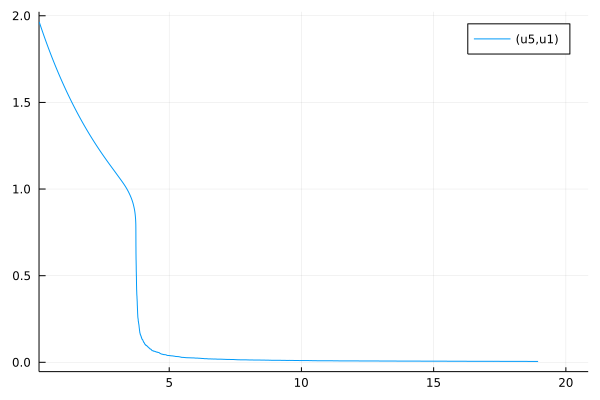

In [16]:
plot(sln, vars=[(5,1)])